## Level 3 - Task 1: Predictive Modeling

In [16]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import mean_squared_error, r2_score

In [17]:
df = pd.read_csv('/content/Dataset .csv')

In [18]:
# Drop missing values
df = df.dropna()

# Convert categorical to numeric
df["Has Table booking"] = df["Has Table booking"].map({"Yes": 1, "No": 0})
df["Has Online delivery"] = df["Has Online delivery"].map({"Yes": 1, "No": 0})

# Select features
features = ["Average Cost for two", "Price range", "Votes",
            "Has Table booking", "Has Online delivery"]

X = df[features]
y = df["Aggregate rating"]

In [19]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [20]:
lr = LinearRegression()
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

print("Linear Regression")
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_lr)))
print("R2 Score:", r2_score(y_test, y_pred_lr))

Linear Regression
RMSE: 1.2757661119895864
R2 Score: 0.289276730828796


In [21]:
dt = DecisionTreeRegressor()
dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)

print("\nDecision Tree")
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_dt)))
print("R2 Score:", r2_score(y_test, y_pred_dt))


Decision Tree
RMSE: 0.4512141810231331
R2 Score: 0.9110954697252331


In [22]:
rf = RandomForestRegressor()
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

print("\nRandom Forest")
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_rf)))
print("R2 Score:", r2_score(y_test, y_pred_rf))


Random Forest
RMSE: 0.3623598647658767
R2 Score: 0.942662521720078


### Predictive Modeling

Regression models were built to predict the aggregate rating of restaurants using features such as average cost, price range, votes, and service availability.

Three models were used: Linear Regression, Decision Tree, and Random Forest.

Among these, the Random Forest model performed the best with lower error and higher R² score, indicating better prediction accuracy.

This shows that ensemble models are more effective for this dataset.

## Level 3 - Task 2: Customer Preference Analysis

In [3]:
df.groupby("Cuisines")["Aggregate rating"].mean().sort_values(ascending=False).head(10)

,Aggregate rating
Cuisines,
"Burger, Bar Food, Steak",4.9
"American, Burger, Grill",4.9
"American, Caribbean, Seafood",4.9
"American, Coffee and Tea",4.9
"Mexican, American, Healthy Food",4.9
"Italian, Bakery, Continental",4.9
"BBQ, Breakfast, Southern",4.9
"European, German",4.9
"Hawaiian, Seafood",4.9


### Cuisine vs Rating Analysis

The analysis shows that certain cuisines such as American, European, and BBQ combinations have the highest average ratings (around 4.9).

However, these cuisines may not necessarily be the most popular, as they could be based on a smaller number of restaurants or votes.

This indicates that while some cuisines achieve very high ratings, they may not represent overall customer preference across the dataset.

In [4]:
df.groupby("Cuisines")["Votes"].sum().sort_values(ascending=False).head(10)

,Votes
Cuisines,
"North Indian, Mughlai",53747
North Indian,46241
"North Indian, Chinese",42012
Cafe,30657
Chinese,21925
"North Indian, Mughlai, Chinese",20115
Fast Food,17852
South Indian,16433
"Mughlai, North Indian",15275


### Customer Preference Analysis

The analysis shows that certain cuisines achieve very high ratings, but they may not be widely popular due to fewer restaurants or votes.

On the other hand, cuisines such as North Indian and Chinese receive a higher number of votes, indicating strong customer preference.

This suggests that popularity and ratings do not always align, and both factors should be considered when analyzing customer preferences.

## Level 3 - Task 3: Data Visualization

In [5]:
import matplotlib.pyplot as plt

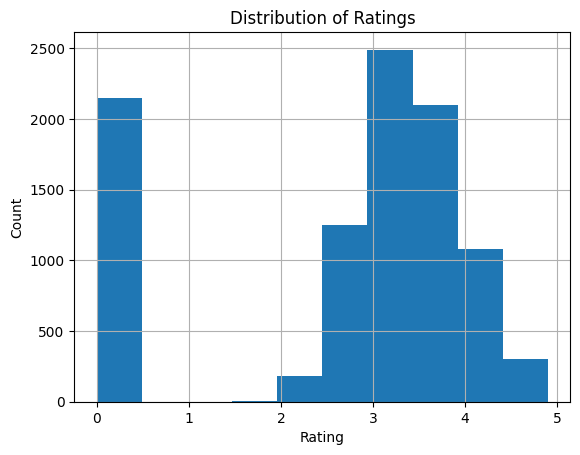

In [6]:
df["Aggregate rating"].hist()
plt.title("Distribution of Ratings")
plt.xlabel("Rating")
plt.ylabel("Count")
plt.show()

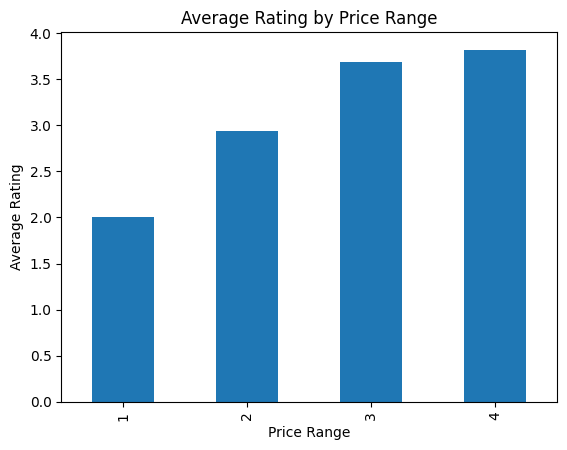

In [7]:
df.groupby("Price range")["Aggregate rating"].mean().plot(kind='bar')
plt.title("Average Rating by Price Range")
plt.xlabel("Price Range")
plt.ylabel("Average Rating")
plt.show()

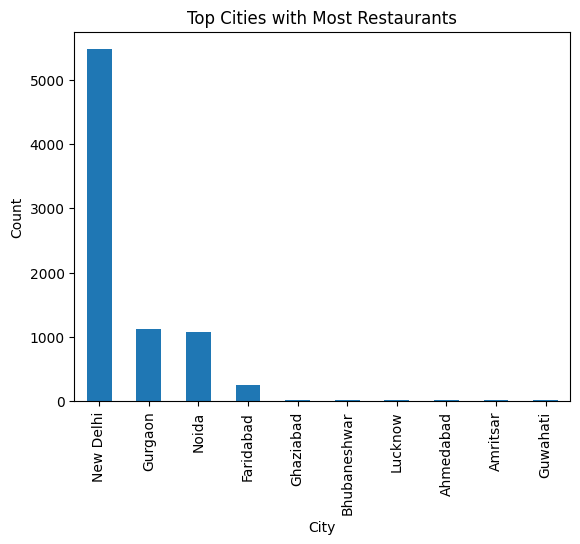

In [8]:
df["City"].value_counts().head(10).plot(kind='bar')
plt.title("Top Cities with Most Restaurants")
plt.xlabel("City")
plt.ylabel("Count")
plt.show()

### Data Visualization

Various visualizations were created to understand the dataset better.

The distribution of ratings shows that most restaurants have moderate ratings.

Bar charts were used to compare ratings across price ranges and to identify cities with the highest number of restaurants.

These visualizations help in identifying patterns and trends in the dataset.